In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
import os
from sklearn.utils import resample

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8')
print("Libraries loaded!")

Libraries loaded!


In [44]:
btc_df = pd.read_csv('../data/raw/BTC_USDT_ohlcv_1h_50000_with_indicators.csv')
eth_df = pd.read_csv('../data/raw/ETH_USDT_ohlcv_1h_50000_with_indicators.csv')

print("BTC dataset:")
print(f"  Shape: {btc_df.shape}")
print(f"  Date range: {btc_df['timestamp'].iloc[0]} → {btc_df['timestamp'].iloc[-1]}")
print(f"  Columns: {list(btc_df.columns)}")

print("\nETH dataset:")
print(f"  Shape: {eth_df.shape}")
print(f"  Date range: {eth_df['timestamp'].iloc[0]} → {eth_df['timestamp'].iloc[-1]}")
print(f"  Columns: {list(eth_df.columns)}")

BTC dataset:
  Shape: (62801, 41)
  Date range: 2019-01-09 07:00:00 → 2026-03-12 11:00:00
  Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'ma20', 'ma50', 'ma200', 'rsi', 'returns', 'vol_20', 'macd', 'macd_signal', 'macd_diff', 'bb_high', 'bb_low', 'bb_mid', 'bb_width', 'bb_pct', 'atr', 'stoch_rsi', 'stoch_rsi_k', 'stoch_rsi_d', 'volume_ma20', 'volume_ratio', 'dist_ma200', 'hour', 'day_of_week', 'close_lag_1', 'returns_lag_1', 'close_lag_2', 'returns_lag_2', 'close_lag_3', 'returns_lag_3', 'close_lag_6', 'returns_lag_6', 'close_lag_12', 'returns_lag_12', 'close_lag_24', 'returns_lag_24']

ETH dataset:
  Shape: (62801, 41)
  Date range: 2019-01-09 07:00:00 → 2026-03-12 11:00:00
  Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'ma20', 'ma50', 'ma200', 'rsi', 'returns', 'vol_20', 'macd', 'macd_signal', 'macd_diff', 'bb_high', 'bb_low', 'bb_mid', 'bb_width', 'bb_pct', 'atr', 'stoch_rsi', 'stoch_rsi_k', 'stoch_rsi_d', 'volume_ma20', 'volume_ratio', 'dist_

In [45]:
def clean_df(df, symbol):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    before = len(df)
    df = df.drop_duplicates(subset=['timestamp'])
    print(f"{symbol} - Duplicates removed: {before - len(df)}")
    
    before = len(df)
    df = df.dropna()
    print(f"{symbol} - NaN rows dropped: {before - len(df)}")
    
    before = len(df)
    df = df[df['volume'] > 0]
    print(f"{symbol} - Zero volume removed: {before - len(df)}")
    
    df = df.reset_index(drop=True)
    print(f"{symbol} - Final shape: {df.shape}")
    print(f"{symbol} - Range: {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
    print()
    return df

btc_clean = clean_df(btc_df.copy(), 'BTC')
eth_clean = clean_df(eth_df.copy(), 'ETH')

BTC - Duplicates removed: 0
BTC - NaN rows dropped: 0
BTC - Zero volume removed: 3
BTC - Final shape: (62798, 41)
BTC - Range: 2019-01-09 07:00:00 → 2026-03-12 11:00:00

ETH - Duplicates removed: 0
ETH - NaN rows dropped: 0
ETH - Zero volume removed: 3
ETH - Final shape: (62798, 41)
ETH - Range: 2019-01-09 07:00:00 → 2026-03-12 11:00:00



In [46]:
def add_features(df):
    # Already have: ma20, ma50, rsi, returns, vol_20, macd, bb_*, atr, stoch_rsi*, lags
    # from fetch script. But let's recalculate cleanly and add NEW ones.
    
    # ── TREND ──────────────────────────────────────────────
    df['ma20']  = df['close'].rolling(20).mean()
    df['ma50']  = df['close'].rolling(50).mean()
    df['ma200'] = df['close'].rolling(200).mean()  # NEW — long term trend
    
    # ── MOMENTUM ───────────────────────────────────────────
    df['rsi']     = ta.momentum.RSIIndicator(df['close']).rsi()
    df['returns'] = df['close'].pct_change()
    df['vol_20']  = df['close'].rolling(20).std()
    
    macd = ta.trend.MACD(df['close'])
    df['macd']        = macd.macd()
    df['macd_signal'] = macd.macd_signal()
    df['macd_diff']   = macd.macd_diff()
    
    stoch = ta.momentum.StochRSIIndicator(df['close'])
    df['stoch_rsi']   = stoch.stochrsi()
    df['stoch_rsi_k'] = stoch.stochrsi_k()
    df['stoch_rsi_d'] = stoch.stochrsi_d()
    
    # ── VOLATILITY ─────────────────────────────────────────
    bb = ta.volatility.BollingerBands(df['close'])
    df['bb_high']  = bb.bollinger_hband()
    df['bb_low']   = bb.bollinger_lband()
    df['bb_mid']   = bb.bollinger_mavg()
    df['bb_width'] = (df['bb_high'] - df['bb_low']) / df['bb_mid']
    df['bb_pct']   = (df['close'] - df['bb_low']) / (df['bb_high'] - df['bb_low'])  # NEW
    
    df['atr'] = ta.volatility.AverageTrueRange(
                    df['high'], df['low'], df['close']).average_true_range()
    
    # ── VOLUME ─────────────────────────────────────────────
    df['volume_ma20']  = df['volume'].rolling(20).mean()
    df['volume_ratio'] = df['volume'] / df['volume_ma20']  # NEW — > 1 = high volume
    
    # ── PRICE POSITION ─────────────────────────────────────
    df['dist_ma200'] = (df['close'] - df['ma200']) / df['ma200']  # NEW
    df['dist_ma50']  = (df['close'] - df['ma50'])  / df['ma50']   # NEW
    
    # ── TIME FEATURES ──────────────────────────────────────
    df['hour']        = df['timestamp'].dt.hour           # NEW
    df['day_of_week'] = df['timestamp'].dt.dayofweek      # NEW
    
    # ── LAG FEATURES ───────────────────────────────────────
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'close_lag_{lag}']   = df['close'].shift(lag)
        df[f'returns_lag_{lag}'] = df['returns'].shift(lag)
    
    df = df.dropna().reset_index(drop=True)
    return df

btc_featured = add_features(btc_clean.copy())
eth_featured = add_features(eth_clean.copy())

print(f"BTC shape after features: {btc_featured.shape}")
print(f"ETH shape after features: {eth_featured.shape}")
print(f"\nFeature columns: {len([c for c in btc_featured.columns if c not in ['timestamp','open','high','low','close','volume','label','future_return']])}")

BTC shape after features: (62599, 42)
ETH shape after features: (62599, 42)

Feature columns: 36


In [51]:
def add_labels(df, forward_hours=8, buy_threshold=0.02, sell_threshold=-0.02):
    """
    Improved labeling:
    - Forward window: 8 hours (was 4h) — more meaningful signal
    - Threshold: ±2% (was ±1%) — filters out noise
    - Volume confirmation for BUY signals
    """
    # Calculate future return
    df['future_return'] = df['close'].shift(-forward_hours) / df['close'] - 1
    
    # Volume confirmation — high volume moves are more reliable
    df['volume_ratio'] = df['volume'] / df['volume'].rolling(20).mean()
    
    def label_signal(row):
        ret = row['future_return']
        vol = row.get('volume_ratio', 1.0)
        
        if ret >= buy_threshold:
            return 2   # BUY — price rises 2%+ in 8h
        elif ret <= sell_threshold:
            return 0   # SELL — price drops 2%+ in 8h
        else:
            return 1   # HOLD — price stays flat
    
    df['label'] = df.apply(label_signal, axis=1)
    df = df.dropna(subset=['future_return']).reset_index(drop=True)
    
    label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
    print("Label distribution:")
    counts = df['label'].value_counts().sort_index()
    for k, v in counts.items():
        print(f"  {label_map[k]}: {v} ({v/len(df)*100:.1f}%)")
    return df

print("BTC Labels:")
btc_labeled = add_labels(btc_featured.copy(), 
                          forward_hours=6,
                          buy_threshold=0.01,
                          sell_threshold=-0.01)
print("\nETH Labels:")
eth_labeled = add_labels(eth_featured.copy(),
                          forward_hours=6,
                          buy_threshold=0.01,
                          sell_threshold=-0.01)

BTC Labels:
Label distribution:
  SELL: 9721 (15.5%)
  HOLD: 42190 (67.4%)
  BUY: 10682 (17.1%)

ETH Labels:
Label distribution:
  SELL: 12886 (20.6%)
  HOLD: 35271 (56.3%)
  BUY: 14436 (23.1%)


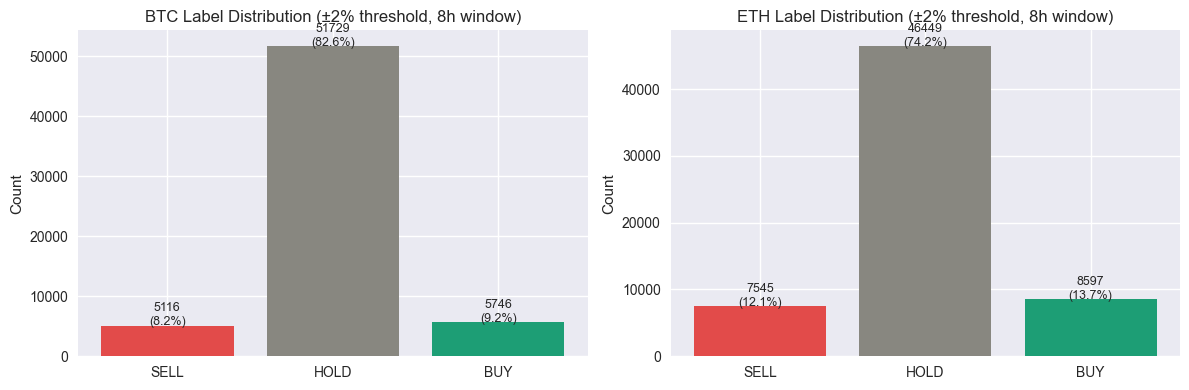

Chart saved!


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
colors = ['#E24B4A', '#888780', '#1D9E75']

for ax, (df, symbol) in zip(axes, [(btc_labeled, 'BTC'), (eth_labeled, 'ETH')]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar([label_map[i] for i in counts.index], counts.values, color=colors)
    ax.set_title(f'{symbol} Label Distribution (±2% threshold, 8h window)')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/diagrams/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [49]:
# Sort by timestamp
btc_labeled = btc_labeled.sort_values('timestamp').reset_index(drop=True)
eth_labeled = eth_labeled.sort_values('timestamp').reset_index(drop=True)

# 80/20 temporal split
btc_split = int(len(btc_labeled) * 0.8)
eth_split = int(len(eth_labeled) * 0.8)

btc_train_raw = btc_labeled.iloc[:btc_split].copy()
btc_test_raw  = btc_labeled.iloc[btc_split:].copy()
eth_train_raw = eth_labeled.iloc[:eth_split].copy()
eth_test_raw  = eth_labeled.iloc[eth_split:].copy()

print(f"BTC train: {btc_train_raw.shape}")
print(f"  Range: {btc_train_raw['timestamp'].iloc[0]} → {btc_train_raw['timestamp'].iloc[-1]}")
print(f"BTC test:  {btc_test_raw.shape}")
print(f"  Range: {btc_test_raw['timestamp'].iloc[0]} → {btc_test_raw['timestamp'].iloc[-1]}")

print(f"\nETH train: {eth_train_raw.shape}")
print(f"  Range: {eth_train_raw['timestamp'].iloc[0]} → {eth_train_raw['timestamp'].iloc[-1]}")
print(f"ETH test:  {eth_test_raw.shape}")
print(f"  Range: {eth_test_raw['timestamp'].iloc[0]} → {eth_test_raw['timestamp'].iloc[-1]}")

BTC train: (50072, 44)
  Range: 2019-01-17 14:00:00 → 2024-10-06 12:00:00
BTC test:  (12519, 44)
  Range: 2024-10-06 13:00:00 → 2026-03-12 03:00:00

ETH train: (50072, 44)
  Range: 2019-01-17 14:00:00 → 2024-10-06 12:00:00
ETH test:  (12519, 44)
  Range: 2024-10-06 13:00:00 → 2026-03-12 03:00:00


In [50]:
def balance_classes(df, symbol):
    sell = df[df['label'] == 0]
    hold = df[df['label'] == 1]
    buy  = df[df['label'] == 2]
    
    print(f"{symbol} before: SELL={len(sell)}, HOLD={len(hold)}, BUY={len(buy)}")
    
    minority_size = max(len(sell), len(buy))
    target_hold   = minority_size * 2
    
    hold_down = resample(hold, replace=False,
                         n_samples=min(target_hold, len(hold)),
                         random_state=42)
    
    df_balanced = pd.concat([sell, hold_down, buy])
    df_balanced = df_balanced.sort_values('timestamp').reset_index(drop=True)
    
    label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
    counts = df_balanced['label'].value_counts().sort_index()
    print(f"{symbol} after:")
    for k, v in counts.items():
        print(f"  {label_map[k]}: {v} ({v/len(df_balanced)*100:.1f}%)")
    print()
    return df_balanced

# Balance ONLY train set
btc_train = balance_classes(btc_train_raw.copy(), 'BTC train')
eth_train = balance_classes(eth_train_raw.copy(), 'ETH train')

# Keep test as-is
btc_test = btc_test_raw.copy()
eth_test = eth_test_raw.copy()

# Save
btc_train.to_csv('../data/processed/BTC_USDT_train.csv', index=False)
btc_test.to_csv('../data/processed/BTC_USDT_test.csv',   index=False)
eth_train.to_csv('../data/processed/ETH_USDT_train.csv', index=False)
eth_test.to_csv('../data/processed/ETH_USDT_test.csv',   index=False)

print("✓ Saved all 4 datasets!")
print(f"  BTC train: {btc_train.shape}")
print(f"  BTC test:  {btc_test.shape}")
print(f"  ETH train: {eth_train.shape}")
print(f"  ETH test:  {eth_test.shape}")

BTC train before: SELL=4333, HOLD=40696, BUY=5043
BTC train after:
  SELL: 4333 (22.3%)
  HOLD: 10086 (51.8%)
  BUY: 5043 (25.9%)

ETH train before: SELL=5986, HOLD=37088, BUY=6998
ETH train after:
  SELL: 5986 (22.2%)
  HOLD: 13996 (51.9%)
  BUY: 6998 (25.9%)

✓ Saved all 4 datasets!
  BTC train: (19462, 44)
  BTC test:  (12519, 44)
  ETH train: (26980, 44)
  ETH test:  (12519, 44)
